# News Topic Modelling with VAE

This notebook compares four topic-modelling scenarios on the same Indonesian news dataset:

1. **LSA** — a classical TF-IDF + TruncatedSVD baseline.
2. **BERTopic** — transformer embeddings + UMAP + HDBSCAN + c-TF-IDF.
3. **VAE + Contextual Embedding** — a VAE trained on contextual sentence embeddings.
4. **VAE + Title-Content Fusion** — a dual-branch VAE that learns from title and content embeddings separately.

The main goal is to keep the comparison fair by using the same dataset split, same text-cleaning pipeline, same target number of topics, same random seed, and the same output schema across all scenarios.

Group Member:
- Syauqi Nabil Tasri (`5054241040`)
- Umar Al Faris (`5054241015`)
- Muhammad Hadidan Nurhaunan (`5054241016`)
- Arvito Rajapandya Natlysandro (`5054241046`)
- Wayan Raditya Putra (`5054241029`)

In [1]:
!pip -q install datasets sentence-transformers bertopic umap-learn hdbscan gensim Sastrawi joblib kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 5.3 MB/s eta 0:00:00


In [2]:
import os
import re
import gc
import json
import math
import random
import shutil
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from datasets import load_dataset

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from joblib import dump

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
DATASET_ID = "lumicero/news-nlp-topic-modelling"
LOCAL_FALLBACK_CSV = "./news-nlp-topic-modelling/dataset_berita_fix.csv"

OUTPUT_ROOT = Path("./news_topic_modelling_outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET_N_TOPICS = 10
TOP_N_WORDS = 10

TITLE_COL = "judul_berita"
CONTENT_COL = "full_text"
AUTHOR_COL = "author"
DATE_COL = "tanggal"
ID_COL = "No"

EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
EMBEDDING_BATCH_SIZE = 32

# Optional stemming can improve classical TF-IDF methods, but it is slower.
# For a fair cross-scenario comparison, this option is applied globally when enabled.
USE_STEMMING = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(RANDOM_STATE)
print("Output root:", OUTPUT_ROOT)
print("Device:", DEVICE)

Output root: news_topic_modelling_outputs
Device: cuda


In [4]:
#@title Utility Function

def clean_filename(name: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_\-]+", "_", str(name)).strip("_").lower()


def scenario_dir(scenario_name: str) -> Path:
    out_dir = OUTPUT_ROOT / clean_filename(scenario_name)
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir


def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def zip_scenario_output(scenario_name: str) -> Path:
    src_dir = scenario_dir(scenario_name)
    zip_base = OUTPUT_ROOT / f"{clean_filename(scenario_name)}_outputs"
    zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=src_dir)
    print(f"[INFO] Zipped {scenario_name} outputs to: {zip_path}")
    return Path(zip_path)


def make_topic_name(topic_id, keywords, max_words=4):
    if int(topic_id) == -1:
        return "Outlier"
    clean_words = [w for w in keywords if isinstance(w, str) and len(w.strip()) > 0]
    if not clean_words:
        return f"Topic {topic_id}"
    return f"Topic {topic_id}: " + ", ".join(clean_words[:max_words])


def plot_topic_distribution(topic_summary_df: pd.DataFrame, scenario_name: str, out_path: Path):
    plot_df = topic_summary_df.copy()
    plot_df["topic_id"] = plot_df["topic_id"].astype(str)
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["topic_id"], plot_df["document_count"])
    plt.title(f"Topic Distribution - {scenario_name}")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Documents")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()


def topic_keywords_from_assignments(texts, labels, vectorizer, top_n=10, exclude_outlier=True):
    # Extract topic keywords by averaging TF-IDF scores within each assigned topic.
    labels = np.asarray(labels)
    unique_topics = sorted(set(labels.tolist()))
    keywords_map = {}

    for topic_id in unique_topics:
        if exclude_outlier and int(topic_id) == -1:
            keywords_map[int(topic_id)] = ["outlier"]
            continue

        idx = np.where(labels == topic_id)[0]
        if len(idx) == 0:
            keywords_map[int(topic_id)] = []
            continue

        topic_tfidf = vectorizer.transform([texts[i] for i in idx])
        mean_scores = np.asarray(topic_tfidf.mean(axis=0)).ravel()

        if mean_scores.sum() == 0:
            keywords_map[int(topic_id)] = []
            continue

        top_indices = mean_scores.argsort()[::-1][:top_n]
        feature_names = np.array(vectorizer.get_feature_names_out())
        keywords_map[int(topic_id)] = feature_names[top_indices].tolist()

    return keywords_map


def build_topic_summary(labels, confidence, keywords_map, scenario_name):
    labels = np.asarray(labels)
    confidence = np.asarray(confidence)
    rows = []
    for topic_id in sorted(set(labels.tolist())):
        idx = np.where(labels == topic_id)[0]
        keywords = keywords_map.get(int(topic_id), [])
        rows.append({
            "scenario": scenario_name,
            "topic_id": int(topic_id),
            "topic_name": make_topic_name(topic_id, keywords),
            "topic_keywords": ", ".join(keywords),
            "document_count": int(len(idx)),
            "avg_confidence": float(np.mean(confidence[idx])) if len(idx) else np.nan,
            "is_outlier": bool(int(topic_id) == -1),
        })
    return pd.DataFrame(rows).sort_values(["is_outlier", "topic_id"]).reset_index(drop=True)


def build_document_output(base_df, text_analyzed, labels, confidence, keywords_map, scenario_name):
    labels = np.asarray(labels)
    confidence = np.asarray(confidence)

    out = pd.DataFrame({
        "doc_id": np.arange(len(base_df)),
        "source_no": base_df[ID_COL].values if ID_COL in base_df.columns else np.arange(1, len(base_df) + 1),
        "title": base_df[TITLE_COL].fillna("").values,
        "author": base_df[AUTHOR_COL].fillna("").values if AUTHOR_COL in base_df.columns else "",
        "date": base_df[DATE_COL].fillna("").values if DATE_COL in base_df.columns else "",
        "full_text": base_df[CONTENT_COL].fillna("").values,
        "text_analyzed": text_analyzed,
        "scenario": scenario_name,
        "topic_id": labels.astype(int),
        "confidence_score": confidence.astype(float),
    })

    out["topic_keywords"] = out["topic_id"].map(lambda t: ", ".join(keywords_map.get(int(t), [])))
    out["topic_name"] = out["topic_id"].map(lambda t: make_topic_name(int(t), keywords_map.get(int(t), [])))
    out["is_outlier"] = out["topic_id"].eq(-1)
    return out


def compute_topic_diversity(keywords_map, top_n=10):
    words = []
    for topic_id, kws in keywords_map.items():
        if int(topic_id) == -1:
            continue
        words.extend(kws[:top_n])
    if len(words) == 0:
        return np.nan
    return len(set(words)) / len(words)


def compute_coherence_scores(tokenized_texts, keywords_map):
    # Compute c_v and u_mass coherence using gensim. Returns NaN if gensim fails.
    valid_topic_words = [
        kws for topic_id, kws in sorted(keywords_map.items())
        if int(topic_id) != -1 and isinstance(kws, list) and len(kws) > 0
    ]

    if len(valid_topic_words) == 0:
        return {"coherence_cv": np.nan, "coherence_umass": np.nan}

    try:
        from gensim.corpora import Dictionary
        from gensim.models import CoherenceModel

        dictionary = Dictionary(tokenized_texts)
        corpus = [dictionary.doc2bow(text) for text in tokenized_texts]

        cm_cv = CoherenceModel(
            topics=valid_topic_words,
            texts=tokenized_texts,
            dictionary=dictionary,
            coherence="c_v",
        )
        cm_umass = CoherenceModel(
            topics=valid_topic_words,
            corpus=corpus,
            dictionary=dictionary,
            coherence="u_mass",
        )

        return {
            "coherence_cv": float(cm_cv.get_coherence()),
            "coherence_umass": float(cm_umass.get_coherence()),
        }
    except Exception as e:
        print("[WARN] Coherence computation failed:", repr(e))
        return {"coherence_cv": np.nan, "coherence_umass": np.nan}


def safe_silhouette(features, labels, random_state=42):
    labels = np.asarray(labels)
    mask = labels != -1

    if mask.sum() < 3:
        return np.nan

    filtered_labels = labels[mask]
    if len(set(filtered_labels.tolist())) < 2:
        return np.nan

    try:
        filtered_features = features[mask]
        sample_size = min(2000, filtered_features.shape[0])
        return float(silhouette_score(
            filtered_features,
            filtered_labels,
            sample_size=sample_size,
            random_state=random_state,
        ))
    except Exception as e:
        print("[WARN] Silhouette computation failed:", repr(e))
        return np.nan


def save_standard_scenario_outputs(
    scenario_name,
    base_df,
    text_analyzed,
    labels,
    confidence,
    keywords_map,
    tokenized_texts,
    feature_for_silhouette=None,
    extra_metrics=None,
    model_objects=None,
):
    # Save document-level output, topic summary, metrics, plots, model objects, and zip the scenario folder.
    out_dir = scenario_dir(scenario_name)

    doc_df = build_document_output(
        base_df=base_df,
        text_analyzed=text_analyzed,
        labels=labels,
        confidence=confidence,
        keywords_map=keywords_map,
        scenario_name=scenario_name,
    )
    topic_summary = build_topic_summary(
        labels=labels,
        confidence=confidence,
        keywords_map=keywords_map,
        scenario_name=scenario_name,
    )

    coherence = compute_coherence_scores(tokenized_texts, keywords_map)
    topic_diversity = compute_topic_diversity(keywords_map, TOP_N_WORDS)

    n_outliers = int(np.sum(np.asarray(labels) == -1))
    valid_topic_count = len([t for t in set(np.asarray(labels).tolist()) if int(t) != -1])

    metrics = {
        "scenario": scenario_name,
        "n_documents": int(len(base_df)),
        "target_n_topics": int(TARGET_N_TOPICS),
        "n_topics_found_excluding_outlier": int(valid_topic_count),
        "outlier_count": int(n_outliers),
        "outlier_ratio": float(n_outliers / len(base_df)),
        "avg_confidence": float(np.mean(confidence)),
        "topic_diversity": float(topic_diversity) if not pd.isna(topic_diversity) else np.nan,
        "coherence_cv": coherence["coherence_cv"],
        "coherence_umass": coherence["coherence_umass"],
    }

    if feature_for_silhouette is not None:
        metrics["silhouette_score"] = safe_silhouette(feature_for_silhouette, labels, RANDOM_STATE)
    else:
        metrics["silhouette_score"] = np.nan

    if extra_metrics:
        metrics.update(extra_metrics)

    doc_path = out_dir / f"{clean_filename(scenario_name)}_document_topics.csv"
    topic_path = out_dir / f"{clean_filename(scenario_name)}_topic_summary.csv"
    metrics_path = out_dir / f"{clean_filename(scenario_name)}_metrics_summary.csv"
    json_path = out_dir / f"{clean_filename(scenario_name)}_metrics_summary.json"

    doc_df.to_csv(doc_path, index=False)
    topic_summary.to_csv(topic_path, index=False)
    pd.DataFrame([metrics]).to_csv(metrics_path, index=False)
    save_json(metrics, json_path)

    plot_topic_distribution(topic_summary, scenario_name, out_dir / f"{clean_filename(scenario_name)}_topic_distribution.png")

    if model_objects:
        model_dir = out_dir / "models"
        model_dir.mkdir(parents=True, exist_ok=True)
        for name, obj in model_objects.items():
            try:
                dump(obj, model_dir / f"{clean_filename(name)}.joblib")
            except Exception as e:
                print(f"[WARN] Could not save {name} with joblib:", repr(e))

    zip_path = zip_scenario_output(scenario_name)

    print(f"[INFO] Saved scenario: {scenario_name}")
    print(f"[INFO] Document output: {doc_path}")
    print(f"[INFO] Topic summary: {topic_path}")
    print(f"[INFO] Metrics: {metrics_path}")
    return {
        "doc_df": doc_df,
        "topic_summary": topic_summary,
        "metrics": metrics,
        "zip_path": zip_path,
    }

## EDA

In [5]:
try:
    dataset = load_dataset(DATASET_ID, split="train")
    raw_df = dataset.to_pandas()
    print(f"[INFO] Loaded dataset from Hugging Face: {DATASET_ID}")
except Exception as e:
    print("[WARN] Hugging Face loading failed:", repr(e))
    print("[INFO] Trying local fallback CSV:", LOCAL_FALLBACK_CSV)
    raw_df = pd.read_csv(LOCAL_FALLBACK_CSV)

print("Shape:", raw_df.shape)
display(raw_df.head())

dataset_berita_fix.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/2587 [00:00<?, ? examples/s]

[INFO] Loaded dataset from Hugging Face: lumicero/news-nlp-topic-modelling
Shape: (2587, 5)


,No,judul_berita,author,tanggal,full_text
0,1,"Impor Minyak Rusia 150 Juta Barel, Hashim Sebu...",Safyra Primadhyta,2026-04-24 21:15:53,Indonesia mengantongi komitmen impor minyak hi...
1,2,"118 Ribu Orang Daftar SDM Kampung Nelayan, Pen...",Safyra Primadhyta,2026-04-24 20:49:45,Kementerian Kelautan dan Perikanan ( KKP ) men...
2,3,Purbaya Bantah Bakal Pungut Pajak Tol dan Oran...,Safyra Primadhyta,2026-04-24 20:36:22,Menteri Keuangan (Menkeu) Purbaya Yudhi Sadewa...
3,4,Kebanggaan Ahmad Dhani di Balik El Rumi Jelang...,Endro Priherdityo,2026-04-24 20:32:51,Ahmad Dhani merasa ada kebanggaan tersendiri m...
4,5,Kata DPR soal Pelaku Wisata Minta Naikkan Kuot...,Windy Wicaksono,2026-04-24 19:54:51,Komisi IV DPR RI bersama Kementerian Kehutanan...


In [6]:
required_columns = [TITLE_COL, CONTENT_COL]
missing_required = [col for col in required_columns if col not in raw_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df = raw_df.copy()

if ID_COL not in df.columns:
    df[ID_COL] = np.arange(1, len(df) + 1)

if AUTHOR_COL not in df.columns:
    df[AUTHOR_COL] = "Unknown"

if DATE_COL not in df.columns:
    df[DATE_COL] = ""

df[TITLE_COL] = df[TITLE_COL].fillna("").astype(str)
df[CONTENT_COL] = df[CONTENT_COL].fillna("").astype(str)
df[AUTHOR_COL] = df[AUTHOR_COL].fillna("Unknown").astype(str)
df[DATE_COL] = df[DATE_COL].fillna("").astype(str)

df["title_length_words"] = df[TITLE_COL].str.split().str.len()
df["content_length_words"] = df[CONTENT_COL].str.split().str.len()
df["combined_length_words"] = df["title_length_words"] + df["content_length_words"]

print("Final shape:", df.shape)
display(df[[ID_COL, TITLE_COL, AUTHOR_COL, DATE_COL, "title_length_words", "content_length_words"]].head())

Final shape: (2587, 8)


,No,judul_berita,author,tanggal,title_length_words,content_length_words
0,1,"Impor Minyak Rusia 150 Juta Barel, Hashim Sebu...",Safyra Primadhyta,2026-04-24 21:15:53,12,260
1,2,"118 Ribu Orang Daftar SDM Kampung Nelayan, Pen...",Safyra Primadhyta,2026-04-24 20:49:45,11,259
2,3,Purbaya Bantah Bakal Pungut Pajak Tol dan Oran...,Safyra Primadhyta,2026-04-24 20:36:22,12,273
3,4,Kebanggaan Ahmad Dhani di Balik El Rumi Jelang...,Endro Priherdityo,2026-04-24 20:32:51,9,293
4,5,Kata DPR soal Pelaku Wisata Minta Naikkan Kuot...,Windy Wicaksono,2026-04-24 19:54:51,11,272


In [7]:
eda_summary = {
    "n_rows": int(len(df)),
    "n_columns": int(df.shape[1]),
    "missing_values": df[[TITLE_COL, CONTENT_COL, AUTHOR_COL, DATE_COL]].isna().sum().to_dict(),
    "title_length_words": df["title_length_words"].describe().to_dict(),
    "content_length_words": df["content_length_words"].describe().to_dict(),
    "combined_length_words": df["combined_length_words"].describe().to_dict(),
}

save_json(eda_summary, OUTPUT_ROOT / "eda_summary.json")

display(pd.DataFrame({
    "column": [TITLE_COL, CONTENT_COL, AUTHOR_COL, DATE_COL],
    "missing_count": [df[c].isna().sum() for c in [TITLE_COL, CONTENT_COL, AUTHOR_COL, DATE_COL]],
    "unique_count": [df[c].nunique() for c in [TITLE_COL, CONTENT_COL, AUTHOR_COL, DATE_COL]],
}))

display(df[["title_length_words", "content_length_words", "combined_length_words"]].describe())

,column,missing_count,unique_count
0,judul_berita,0,2585
1,full_text,0,2587
2,author,0,49
3,tanggal,0,2587


,title_length_words,content_length_words,combined_length_words
count,2587.000000,2587.000000,2587.000000
mean,9.437572,254.846154,264.283726
std,1.354245,35.027725,35.161762
min,4.000000,0.000000,10.000000
25%,9.000000,251.000000,260.000000
50%,9.000000,264.000000,274.000000
75%,10.000000,275.000000,284.000000
max,14.000000,325.000000,335.000000


,author,count
0,Moh Rusdi,296
1,Safyra Primadhyta,259
2,Unknown,202
3,Putri Utami,174
4,Agus Triyono,152
5,Indra Hendriana,109
6,Feri Agus,103
7,Isnaini,87
8,Fersita Facette,84
9,Ihsan Dalimunthe,80


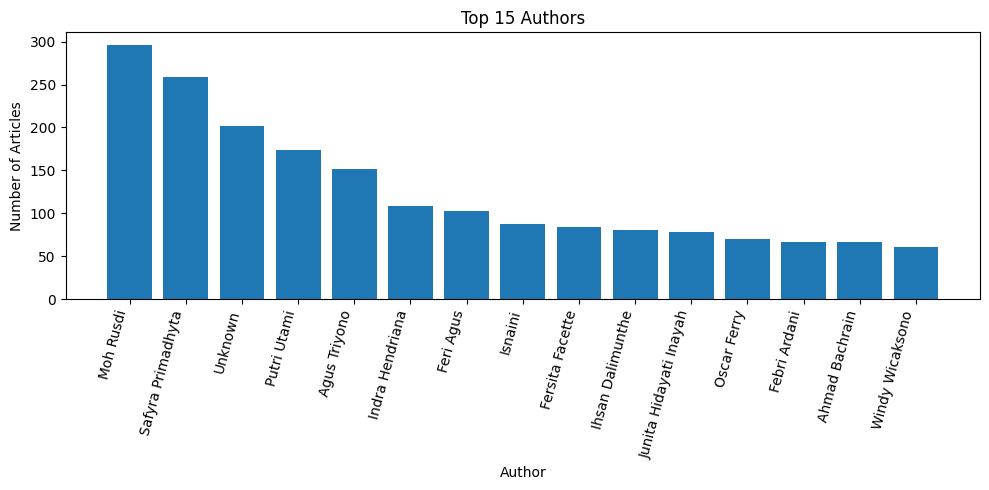

In [8]:
top_authors = df[AUTHOR_COL].value_counts().head(15).reset_index()
top_authors.columns = ["author", "count"]
display(top_authors)

plt.figure(figsize=(10, 5))
plt.bar(top_authors["author"], top_authors["count"])
plt.title("Top 15 Authors")
plt.xlabel("Author")
plt.ylabel("Number of Articles")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "eda_top_authors.png", dpi=150)
plt.show()

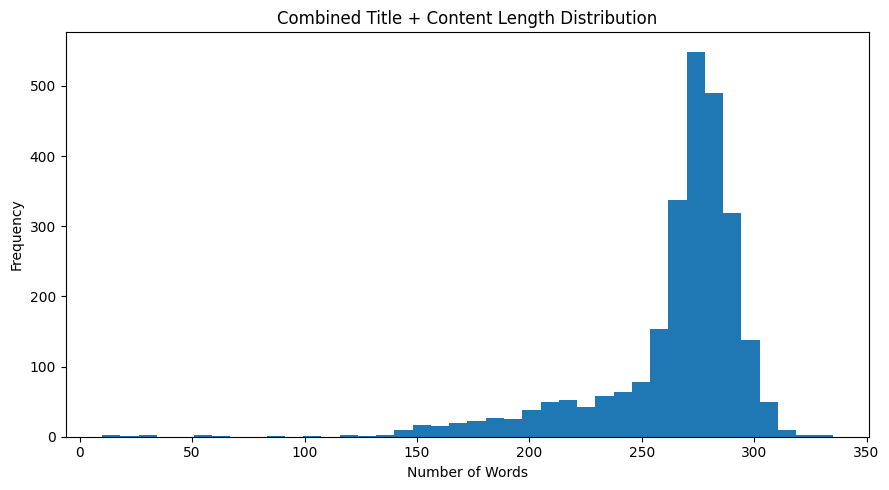

In [9]:
plt.figure(figsize=(9, 5))
plt.hist(df["combined_length_words"], bins=40)
plt.title("Combined Title + Content Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "eda_document_length_distribution.png", dpi=150)
plt.show()

Min date: 2024-05-29 08:30:26
Max date: 2026-04-24 21:15:53
Unparsed dates: 0


,_parsed_date,count
19,2025-12-31,165
20,2026-01-31,202
21,2026-02-28,243
22,2026-03-31,258
23,2026-04-30,540


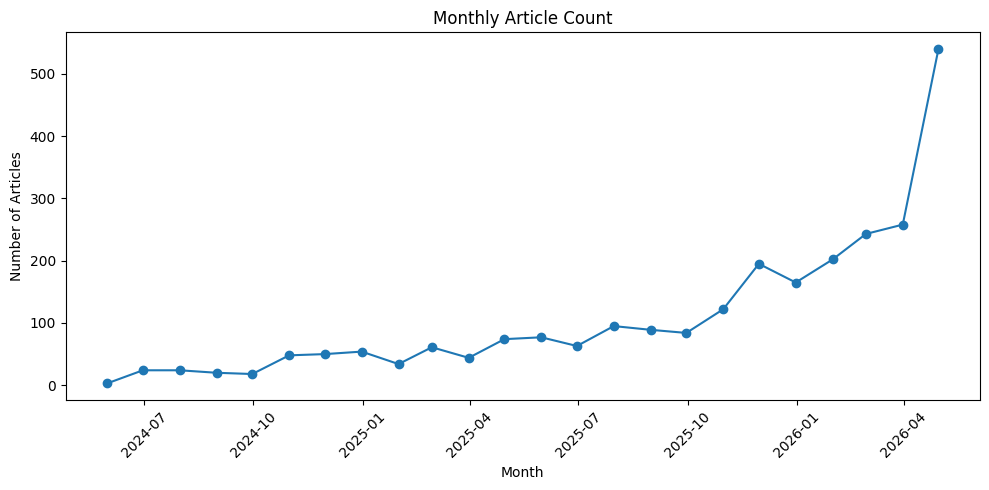

In [10]:
df["_parsed_date"] = pd.to_datetime(df[DATE_COL], errors="coerce")
print("Min date:", df["_parsed_date"].min())
print("Max date:", df["_parsed_date"].max())
print("Unparsed dates:", df["_parsed_date"].isna().sum())

monthly_counts = (
    df.dropna(subset=["_parsed_date"])
      .set_index("_parsed_date")
      .resample("M")
      .size()
      .reset_index(name="count")
)

display(monthly_counts.tail())

if len(monthly_counts) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(monthly_counts["_parsed_date"], monthly_counts["count"], marker="o")
    plt.title("Monthly Article Count")
    plt.xlabel("Month")
    plt.ylabel("Number of Articles")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "eda_monthly_article_count.png", dpi=150)
    plt.show()

## Preprocess

In [11]:
stopword_factory = StopWordRemoverFactory()
base_stopwords = set(stopword_factory.get_stop_words())

custom_stopwords = {
    "cnn", "indonesia", "com", "detik", "jakarta", "ujar", "kata", "mengatakan",
    "dalam", "pada", "dengan", "untuk", "yang", "dan", "di", "ke", "dari",
    "ini", "itu", "atau", "akan", "telah", "sudah", "juga", "karena", "sebagai",
    "ada", "menjadi", "hingga", "tersebut", "secara", "sejumlah", "saat",
    "hari", "tahun", "bulan", "orang", "rp", "ribu", "juta", "miliar", "triliun"
}

STOPWORDS = base_stopwords.union(custom_stopwords)

stemmer = None
if USE_STEMMING:
    stemmer = StemmerFactory().create_stemmer()


def basic_clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_and_filter(text: str):
    tokens = basic_clean_text(text).split()
    tokens = [tok for tok in tokens if tok not in STOPWORDS and len(tok) > 2]
    if USE_STEMMING and stemmer is not None:
        tokens = [stemmer.stem(tok) for tok in tokens]
    return tokens


def preprocess_text(text: str) -> str:
    return " ".join(tokenize_and_filter(text))

In [12]:
df["title_raw"] = df[TITLE_COL].fillna("").astype(str)
df["content_raw"] = df[CONTENT_COL].fillna("").astype(str)

df["text_raw_combined"] = (df["title_raw"] + ". " + df["content_raw"]).str.strip()
df["title_clean"] = df["title_raw"].apply(preprocess_text)
df["content_clean"] = df["content_raw"].apply(preprocess_text)
df["text_clean"] = df["text_raw_combined"].apply(preprocess_text)

# Remove empty cleaned documents, if any.
before_count = len(df)
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)
after_count = len(df)

tokenized_texts = df["text_clean"].str.split().tolist()

print(f"[INFO] Documents before filtering: {before_count}")
print(f"[INFO] Documents after filtering : {after_count}")
display(df[[ID_COL, TITLE_COL, "title_clean", "content_clean", "text_clean"]].head())

[INFO] Documents before filtering: 2587
[INFO] Documents after filtering : 2587


,No,judul_berita,title_clean,content_clean,text_clean
0,1,"Impor Minyak Rusia 150 Juta Barel, Hashim Sebu...",impor minyak rusia barel hashim sebut harga kh...,mengantongi komitmen impor minyak barel harga ...,impor minyak rusia barel hashim sebut harga kh...
1,2,"118 Ribu Orang Daftar SDM Kampung Nelayan, Pen...",daftar sdm kampung nelayan pendaftaran tutup,kementerian kelautan perikanan kkp mencatat ra...,daftar sdm kampung nelayan pendaftaran tutup k...
2,3,Purbaya Bantah Bakal Pungut Pajak Tol dan Oran...,purbaya bantah bakal pungut pajak tol kaya wak...,menteri keuangan menkeu purbaya yudhi sadewa m...,purbaya bantah bakal pungut pajak tol kaya wak...
3,4,Kebanggaan Ahmad Dhani di Balik El Rumi Jelang...,kebanggaan ahmad dhani balik rumi jelang menikah,ahmad dhani merasa kebanggaan tersendiri menje...,kebanggaan ahmad dhani balik rumi jelang menik...
4,5,Kata DPR soal Pelaku Wisata Minta Naikkan Kuot...,dpr soal pelaku wisata minta naikkan kuota pen...,komisi dpr bersama kementerian kehutanan mengg...,dpr soal pelaku wisata minta naikkan kuota pen...


In [13]:
preprocess_out = OUTPUT_ROOT / "preprocessed_dataset.csv"
df.to_csv(preprocess_out, index=False)
print("[INFO] Saved:", preprocess_out)

[INFO] Saved: news_topic_modelling_outputs/preprocessed_dataset.csv


## Feature Engineering

In [14]:
TFIDF_MAX_FEATURES = 10000
TFIDF_MIN_DF = 2
TFIDF_MAX_DF = 0.90
TFIDF_NGRAM_RANGE = (1, 2)

tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
    ngram_range=TFIDF_NGRAM_RANGE,
    sublinear_tf=True,
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df["text_clean"].tolist())
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

print("TF-IDF matrix shape:", tfidf_matrix.shape)

dump(tfidf_vectorizer, OUTPUT_ROOT / "shared_tfidf_vectorizer.joblib")

TF-IDF matrix shape: (2587, 10000)


['news_topic_modelling_outputs/shared_tfidf_vectorizer.joblib']

In [15]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)
print("Loaded embedding model:", EMBEDDING_MODEL_NAME)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded embedding model: paraphrase-multilingual-MiniLM-L12-v2


In [16]:
embedding_texts = df["text_raw_combined"].fillna("").astype(str).tolist()

doc_embeddings = embedding_model.encode(
    embedding_texts,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print("Document embeddings shape:", doc_embeddings.shape)
np.save(OUTPUT_ROOT / "shared_doc_embeddings.npy", doc_embeddings)

Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Document embeddings shape: (2587, 384)


In [17]:
title_embeddings = embedding_model.encode(
    df["title_raw"].fillna("").astype(str).tolist(),
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

content_embeddings = embedding_model.encode(
    df["content_raw"].fillna("").astype(str).tolist(),
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print("Title embeddings shape:", title_embeddings.shape)
print("Content embeddings shape:", content_embeddings.shape)

np.save(OUTPUT_ROOT / "shared_title_embeddings.npy", title_embeddings)
np.save(OUTPUT_ROOT / "shared_content_embeddings.npy", content_embeddings)

Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Title embeddings shape: (2587, 384)
Content embeddings shape: (2587, 384)


## LDA

In [18]:
SCENARIO_NAME = "LSA"

lsa_model = TruncatedSVD(
    n_components=TARGET_N_TOPICS,
    random_state=RANDOM_STATE,
    n_iter=20,
)

lsa_doc_topic_raw = lsa_model.fit_transform(tfidf_matrix)

# LSA components can contain negative values, so confidence is treated as a heuristic.
lsa_abs_scores = np.abs(lsa_doc_topic_raw)
lsa_row_sums = lsa_abs_scores.sum(axis=1, keepdims=True)
lsa_topic_distribution = lsa_abs_scores / np.clip(lsa_row_sums, 1e-12, None)

lsa_labels = np.argmax(lsa_topic_distribution, axis=1)
lsa_confidence = np.max(lsa_topic_distribution, axis=1)

# Topic keywords from positive SVD component weights.
lsa_keywords_map = {}
for topic_id, component in enumerate(lsa_model.components_):
    top_indices = component.argsort()[::-1][:TOP_N_WORDS]
    lsa_keywords_map[int(topic_id)] = feature_names[top_indices].tolist()

print("[INFO] LSA explained variance ratio sum:", float(lsa_model.explained_variance_ratio_.sum()))
print("[INFO] LSA labels:", Counter(lsa_labels))

[INFO] LSA explained variance ratio sum: 0.061665408708355574
[INFO] LSA labels: Counter({np.int64(0): 1887, np.int64(1): 161, np.int64(6): 125, np.int64(5): 72, np.int64(4): 71, np.int64(3): 66, np.int64(9): 59, np.int64(7): 56, np.int64(2): 52, np.int64(8): 38})


In [19]:
lsa_result = save_standard_scenario_outputs(
    scenario_name=SCENARIO_NAME,
    base_df=df,
    text_analyzed=df["text_clean"].tolist(),
    labels=lsa_labels,
    confidence=lsa_confidence,
    keywords_map=lsa_keywords_map,
    tokenized_texts=tokenized_texts,
    feature_for_silhouette=lsa_topic_distribution,
    extra_metrics={
        "lsa_explained_variance_ratio_sum": float(lsa_model.explained_variance_ratio_.sum()),
    },
    model_objects={
        "lsa_model": lsa_model,
        "tfidf_vectorizer": tfidf_vectorizer,
    },
)

display(lsa_result["topic_summary"])
display(pd.DataFrame([lsa_result["metrics"]]))

[INFO] Zipped LSA outputs to: /content/news_topic_modelling_outputs/lsa_outputs.zip
[INFO] Saved scenario: LSA
[INFO] Document output: news_topic_modelling_outputs/lsa/lsa_document_topics.csv
[INFO] Topic summary: news_topic_modelling_outputs/lsa/lsa_topic_summary.csv
[INFO] Metrics: news_topic_modelling_outputs/lsa/lsa_metrics_summary.csv


,scenario,topic_id,topic_name,topic_keywords,document_count,avg_confidence,is_outlier
0,LSA,0,"Topic 0: ekonomi, nasional, persen, pemerintah","ekonomi, nasional, persen, pemerintah, lebih, ...",1887,0.336517,False
1,LSA,1,"Topic 1: persen, pertumbuhan, ekonomi, pertumb...","persen, pertumbuhan, ekonomi, pertumbuhan ekon...",161,0.232233,False
2,LSA,2,"Topic 2: persen, pahlawan, pahlawan nasional, ...","persen, pahlawan, pahlawan nasional, kuartal, ...",52,0.271865,False
3,LSA,3,"Topic 3: pahlawan, pahlawan nasional, gelar, s...","pahlawan, pahlawan nasional, gelar, soeharto, ...",66,0.222240,False
4,LSA,4,"Topic 4: libur, libur nasional, cuti, cuti ber...","libur, libur nasional, cuti, cuti bersama, nas...",71,0.346306,False
5,LSA,5,"Topic 5: bencana, aceh, banjir, sumatra","bencana, aceh, banjir, sumatra, bencana nasion...",72,0.292068,False
6,LSA,6,"Topic 6: harga, energi, minyak, pasokan","harga, energi, minyak, pasokan, bbm, pahlawan ...",125,0.228154,False
7,LSA,7,"Topic 7: magang, magang nasional, peserta, kem...","magang, magang nasional, peserta, kemnaker, ba...",56,0.298184,False
8,LSA,8,"Topic 8: prabowo, presiden, gizi, mbg","prabowo, presiden, gizi, mbg, presiden prabowo...",38,0.275981,False
9,LSA,9,"Topic 9: kendaraan, mobil, one way, way","kendaraan, mobil, one way, way, one, arus, agu...",59,0.317987,False


,scenario,n_documents,target_n_topics,n_topics_found_excluding_outlier,outlier_count,outlier_ratio,avg_confidence,topic_diversity,coherence_cv,coherence_umass,silhouette_score,lsa_explained_variance_ratio_sum
0,LSA,2587,10,10,0,0.0,0.317466,0.81,0.705994,-1.947539,0.068925,0.061665


## BERTopic

In [20]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

SCENARIO_NAME = "BERTopic"

# Fixed-random-state UMAP improves reproducibility.
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

# CountVectorizer is used internally by BERTopic for c-TF-IDF topic words.
bertopic_vectorizer = CountVectorizer(
    stop_words=list(STOPWORDS),
    ngram_range=(1, 2),
    min_df=2,
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=bertopic_vectorizer,
    language="multilingual",
    nr_topics=TARGET_N_TOPICS,
    top_n_words=TOP_N_WORDS,
    calculate_probabilities=True,
    verbose=True,
)

bertopic_topics, bertopic_probs = topic_model.fit_transform(
    embedding_texts,
    embeddings=doc_embeddings,
)

bertopic_labels = np.array(bertopic_topics, dtype=int)

# Confidence extraction. Keep BERTopic's assigned labels as labels.
if bertopic_probs is None:
    bertopic_confidence = np.ones(len(bertopic_labels), dtype=float)
else:
    bertopic_probs = np.asarray(bertopic_probs)
    if bertopic_probs.ndim == 1:
        bertopic_confidence = bertopic_probs.astype(float)
    else:
        bertopic_confidence = np.max(bertopic_probs, axis=1).astype(float)

bertopic_keywords_map = {}
for topic_id in sorted(set(bertopic_labels.tolist())):
    if int(topic_id) == -1:
        bertopic_keywords_map[int(topic_id)] = ["outlier"]
    else:
        topic_words = topic_model.get_topic(int(topic_id))
        bertopic_keywords_map[int(topic_id)] = [word for word, score in topic_words[:TOP_N_WORDS]]

print("[INFO] BERTopic labels:", Counter(bertopic_labels))
display(topic_model.get_topic_info().head(15))

2026-04-26 08:05:13,650 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 08:05:38,617 - BERTopic - Dimensionality - Completed ✓
2026-04-26 08:05:38,619 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 08:05:39,250 - BERTopic - Cluster - Completed ✓
2026-04-26 08:05:39,252 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-26 08:05:40,429 - BERTopic - Representation - Completed ✓
2026-04-26 08:05:40,432 - BERTopic - Topic reduction - Reducing number of topics
2026-04-26 08:05:40,448 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 08:05:41,676 - BERTopic - Representation - Completed ✓
2026-04-26 08:05:41,679 - BERTopic - Topic reduction - Reduced number of topics from 67 to 10


[INFO] BERTopic labels: Counter({np.int64(0): 988, np.int64(-1): 502, np.int64(1): 371, np.int64(2): 254, np.int64(3): 126, np.int64(4): 110, np.int64(5): 80, np.int64(6): 68, np.int64(7): 60, np.int64(8): 28})


,Topic,Count,Name,Representation,Representative_Docs
0,-1,502,-1_ekonomi_persen_nasional_pemerintah,"[ekonomi, persen, nasional, pemerintah, negara...",[MBG Perkuat Fondasi Ekonomi Nasional dan Doro...
1,0,988,0_ekonomi_persen_nasional_pertumbuhan,"[ekonomi, persen, nasional, pertumbuhan, pemer...","[Ekonomi RI Diramal Cuma Tumbuh 4,7 Persen, Pr..."
2,1,371,1_nasional_pahlawan_pahlawan nasional_presiden,"[nasional, pahlawan, pahlawan nasional, presid...",[Presiden Prabowo Kaji Usulan 40 Pahlawan Nasi...
3,2,254,2_nasional_libur_bersama_anak,"[nasional, libur, bersama, anak, guru, 2025, l...",[Kapan Cuti Bersama Natal 2025? Cek Jadwalnya ...
4,3,126,3_iran_israel_as_serangan,"[iran, israel, as, serangan, perang, trump, ne...","[Israel Gempur Teheran, Bom Kantor Presiden & ..."
5,4,110,4_bencana_nasional_sumatra_banjir,"[bencana, nasional, sumatra, banjir, arus, ace...",[Update Korban Banjir-Longsor Sumatra: 836 Men...
6,5,80,5_pemain_timnas_tim_pelatih,"[pemain, timnas, tim, pelatih, piala, tim nasi...",[Reaksi Pelatih Persija Herdman Latih Timnas: ...
7,6,68,6_magang_peserta_magang nasional_kemnaker,"[magang, peserta, magang nasional, kemnaker, b...",[Kapan Pengumuman Hasil Seleksi Magang Nasiona...
8,7,60,7_harga_per_kg_per kg,"[harga, per, kg, per kg, cabai, minyak, persen...","[Hampir 10 Hari Jelang Lebaran, Harga Ayam dan..."
9,8,28,8_trump_venezuela_garda nasional_garda,"[trump, venezuela, garda nasional, garda, as, ...",[Trump Digugat Illinois buntut Kerahkan Garda ...


In [21]:
# Save BERTopic visualizations as HTML if available.

bertopic_out_dir = scenario_dir(SCENARIO_NAME)

try:
    fig = topic_model.visualize_topics()
    fig.write_html(str(bertopic_out_dir / "bertopic_topic_map.html"))
except Exception as e:
    print("[WARN] Could not save BERTopic topic map:", repr(e))

try:
    fig = topic_model.visualize_barchart(top_n_topics=TARGET_N_TOPICS)
    fig.write_html(str(bertopic_out_dir / "bertopic_barchart.html"))
except Exception as e:
    print("[WARN] Could not save BERTopic barchart:", repr(e))

try:
    fig = topic_model.visualize_heatmap()
    fig.write_html(str(bertopic_out_dir / "bertopic_heatmap.html"))
except Exception as e:
    print("[WARN] Could not save BERTopic heatmap:", repr(e))

In [22]:
bertopic_result = save_standard_scenario_outputs(
    scenario_name=SCENARIO_NAME,
    base_df=df,
    text_analyzed=df["text_clean"].tolist(),
    labels=bertopic_labels,
    confidence=bertopic_confidence,
    keywords_map=bertopic_keywords_map,
    tokenized_texts=tokenized_texts,
    feature_for_silhouette=doc_embeddings,
    extra_metrics={
        "bertopic_min_topic_size": 10,
        "bertopic_nr_topics": TARGET_N_TOPICS,
    },
    model_objects={
        "bertopic_count_vectorizer": bertopic_vectorizer,
    },
)

# Save the BERTopic model separately.
# Safetensors is compact; pickle fallback is included for compatibility.
model_save_dir = scenario_dir(SCENARIO_NAME) / "models" / "bertopic_model"
model_save_dir.mkdir(parents=True, exist_ok=True)

try:
    topic_model.save(
        str(model_save_dir),
        serialization="safetensors",
        save_ctfidf=True,
        save_embedding_model=EMBEDDING_MODEL_NAME,
    )
    print("[INFO] BERTopic model saved with safetensors:", model_save_dir)
except Exception as e:
    print("[WARN] Safetensors save failed, trying pickle:", repr(e))
    topic_model.save(str(model_save_dir / "bertopic_model_pickle"))
    print("[INFO] BERTopic model saved with pickle fallback.")

# Re-zip after saving the BERTopic model.
zip_scenario_output(SCENARIO_NAME)

display(bertopic_result["topic_summary"])
display(pd.DataFrame([bertopic_result["metrics"]]))

[INFO] Zipped BERTopic outputs to: /content/news_topic_modelling_outputs/bertopic_outputs.zip
[INFO] Saved scenario: BERTopic
[INFO] Document output: news_topic_modelling_outputs/bertopic/bertopic_document_topics.csv
[INFO] Topic summary: news_topic_modelling_outputs/bertopic/bertopic_topic_summary.csv
[INFO] Metrics: news_topic_modelling_outputs/bertopic/bertopic_metrics_summary.csv
[INFO] BERTopic model saved with safetensors: news_topic_modelling_outputs/bertopic/models/bertopic_model
[INFO] Zipped BERTopic outputs to: /content/news_topic_modelling_outputs/bertopic_outputs.zip


,scenario,topic_id,topic_name,topic_keywords,document_count,avg_confidence,is_outlier
0,BERTopic,0,"Topic 0: ekonomi, persen, nasional, pertumbuhan","ekonomi, persen, nasional, pertumbuhan, pemeri...",988,0.653152,False
1,BERTopic,1,"Topic 1: nasional, pahlawan, pahlawan nasional...","nasional, pahlawan, pahlawan nasional, preside...",371,0.705461,False
2,BERTopic,2,"Topic 2: nasional, libur, bersama, anak","nasional, libur, bersama, anak, guru, 2025, li...",254,0.627484,False
3,BERTopic,3,"Topic 3: iran, israel, as, serangan","iran, israel, as, serangan, perang, trump, neg...",126,0.558196,False
4,BERTopic,4,"Topic 4: bencana, nasional, sumatra, banjir","bencana, nasional, sumatra, banjir, arus, aceh...",110,0.830583,False
5,BERTopic,5,"Topic 5: pemain, timnas, tim, pelatih","pemain, timnas, tim, pelatih, piala, tim nasio...",80,0.543913,False
6,BERTopic,6,"Topic 6: magang, peserta, magang nasional, kem...","magang, peserta, magang nasional, kemnaker, ba...",68,0.772651,False
7,BERTopic,7,"Topic 7: harga, per, kg, per kg","harga, per, kg, per kg, cabai, minyak, persen,...",60,0.713565,False
8,BERTopic,8,"Topic 8: trump, venezuela, garda nasional, garda","trump, venezuela, garda nasional, garda, as, p...",28,0.843681,False
9,BERTopic,-1,Outlier,outlier,502,0.263751,True


,scenario,n_documents,target_n_topics,n_topics_found_excluding_outlier,outlier_count,outlier_ratio,avg_confidence,topic_diversity,coherence_cv,coherence_umass,silhouette_score,bertopic_min_topic_size,bertopic_nr_topics
0,BERTopic,2587,10,9,502,0.194047,0.588717,0.877778,0.67755,-2.314108,0.048006,10,10


## VAE + Contextual Embedding

In [23]:
# VAE training utilities.

class EmbeddingVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=256, dropout=0.10):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar


def vae_loss_function(recon_x, x, mu, logvar, beta=0.01):
    recon_loss = F.mse_loss(recon_x, x, reduction="mean")
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss = recon_loss + beta * kld
    return loss, recon_loss, kld


def train_embedding_vae(
    features,
    latent_dim,
    hidden_dim=256,
    dropout=0.10,
    lr=1e-3,
    batch_size=128,
    epochs=80,
    beta=0.01,
    patience=15,
    scenario_name="vae_contextual",
):
    set_seed(RANDOM_STATE)

    x_train, x_val = train_test_split(
        features,
        test_size=0.10,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    train_loader = DataLoader(
        TensorDataset(torch.tensor(x_train, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(x_val, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
    )

    model = EmbeddingVAE(
        input_dim=features.shape[1],
        latent_dim=latent_dim,
        hidden_dim=hidden_dim,
        dropout=dropout,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = []
    best_val = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses, train_recons, train_klds = [], [], []

        for (batch_x,) in train_loader:
            batch_x = batch_x.to(DEVICE)
            optimizer.zero_grad()
            recon, mu, logvar = model(batch_x)
            loss, recon_loss, kld = vae_loss_function(recon, batch_x, mu, logvar, beta=beta)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_losses.append(loss.item())
            train_recons.append(recon_loss.item())
            train_klds.append(kld.item())

        model.eval()
        val_losses, val_recons, val_klds = [], [], []
        with torch.no_grad():
            for (batch_x,) in val_loader:
                batch_x = batch_x.to(DEVICE)
                recon, mu, logvar = model(batch_x)
                loss, recon_loss, kld = vae_loss_function(recon, batch_x, mu, logvar, beta=beta)
                val_losses.append(loss.item())
                val_recons.append(recon_loss.item())
                val_klds.append(kld.item())

        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "train_recon_loss": float(np.mean(train_recons)),
            "train_kld": float(np.mean(train_klds)),
            "val_loss": float(np.mean(val_losses)),
            "val_recon_loss": float(np.mean(val_recons)),
            "val_kld": float(np.mean(val_klds)),
        }
        history.append(row)

        print(
            f"[INFO] {scenario_name} | Epoch {epoch:03d}/{epochs} | "
            f"train_loss={row['train_loss']:.6f} | val_loss={row['val_loss']:.6f} | "
            f"val_recon={row['val_recon_loss']:.6f} | val_kld={row['val_kld']:.6f}"
        )

        if row["val_loss"] < best_val:
            best_val = row["val_loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"[INFO] Early stopping at epoch {epoch}. Best val_loss={best_val:.6f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    return model, history_df


def get_embedding_vae_latent(model, features, batch_size=256):
    loader = DataLoader(
        TensorDataset(torch.tensor(features, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
    )

    model.eval()
    mus, logvars = [], []
    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(DEVICE)
            mu, logvar = model.encode(batch_x)
            mus.append(mu.cpu().numpy())
            logvars.append(logvar.cpu().numpy())

    return np.vstack(mus), np.vstack(logvars)


def kmeans_topics_from_latent(latent_features, n_topics=10):
    kmeans = KMeans(
        n_clusters=n_topics,
        random_state=RANDOM_STATE,
        n_init=20,
    )
    labels = kmeans.fit_predict(latent_features)

    distances = kmeans.transform(latent_features)
    similarity = -distances
    similarity = similarity - similarity.max(axis=1, keepdims=True)
    probs = np.exp(similarity)
    probs = probs / np.clip(probs.sum(axis=1, keepdims=True), 1e-12, None)
    confidence = probs.max(axis=1)

    return labels.astype(int), confidence.astype(float), kmeans, probs

[INFO] VAE_Contextual_Embedding | Epoch 001/80 | train_loss=1.011100 | val_loss=0.953072 | val_recon=0.942919 | val_kld=1.015325
[INFO] VAE_Contextual_Embedding | Epoch 002/80 | train_loss=0.872412 | val_loss=0.828741 | val_recon=0.813538 | val_kld=1.520348
[INFO] VAE_Contextual_Embedding | Epoch 003/80 | train_loss=0.777789 | val_loss=0.747035 | val_recon=0.729331 | val_kld=1.770432
[INFO] VAE_Contextual_Embedding | Epoch 004/80 | train_loss=0.720760 | val_loss=0.703820 | val_recon=0.684518 | val_kld=1.930185
[INFO] VAE_Contextual_Embedding | Epoch 005/80 | train_loss=0.686329 | val_loss=0.671602 | val_recon=0.651171 | val_kld=2.043089
[INFO] VAE_Contextual_Embedding | Epoch 006/80 | train_loss=0.655794 | val_loss=0.651451 | val_recon=0.630190 | val_kld=2.126024
[INFO] VAE_Contextual_Embedding | Epoch 007/80 | train_loss=0.639836 | val_loss=0.631415 | val_recon=0.610205 | val_kld=2.121015
[INFO] VAE_Contextual_Embedding | Epoch 008/80 | train_loss=0.624273 | val_loss=0.614554 | val_re

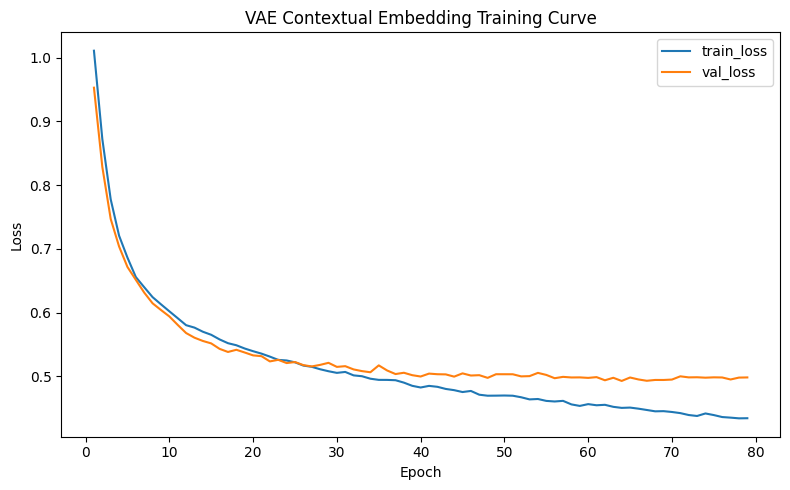

In [24]:
# Train VAE on contextual document embeddings.

SCENARIO_NAME = "VAE_Contextual_Embedding"

context_scaler = StandardScaler()
context_features = context_scaler.fit_transform(doc_embeddings).astype(np.float32)

vae_context_model, vae_context_history = train_embedding_vae(
    features=context_features,
    latent_dim=TARGET_N_TOPICS,
    hidden_dim=256,
    dropout=0.10,
    lr=1e-3,
    batch_size=128,
    epochs=80,
    beta=0.01,
    patience=15,
    scenario_name=SCENARIO_NAME,
)

context_out_dir = scenario_dir(SCENARIO_NAME)
vae_context_history.to_csv(context_out_dir / "vae_training_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(vae_context_history["epoch"], vae_context_history["train_loss"], label="train_loss")
plt.plot(vae_context_history["epoch"], vae_context_history["val_loss"], label="val_loss")
plt.title("VAE Contextual Embedding Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(context_out_dir / "vae_training_curve.png", dpi=150)
plt.show()

In [25]:
# Extract latent features and topics.

vae_context_mu, vae_context_logvar = get_embedding_vae_latent(
    vae_context_model,
    context_features,
)

vae_context_labels, vae_context_confidence, vae_context_kmeans, vae_context_probs = kmeans_topics_from_latent(
    vae_context_mu,
    n_topics=TARGET_N_TOPICS,
)

vae_context_keywords_map = topic_keywords_from_assignments(
    texts=df["text_clean"].tolist(),
    labels=vae_context_labels,
    vectorizer=tfidf_vectorizer,
    top_n=TOP_N_WORDS,
    exclude_outlier=False,
)

print("[INFO] VAE contextual labels:", Counter(vae_context_labels))
np.save(context_out_dir / "vae_context_latent_mu.npy", vae_context_mu)
np.save(context_out_dir / "vae_context_topic_probabilities.npy", vae_context_probs)

[INFO] VAE contextual labels: Counter({np.int64(2): 369, np.int64(0): 358, np.int64(4): 308, np.int64(7): 253, np.int64(6): 250, np.int64(9): 243, np.int64(8): 233, np.int64(5): 203, np.int64(3): 186, np.int64(1): 184})


In [26]:
vae_context_result = save_standard_scenario_outputs(
    scenario_name=SCENARIO_NAME,
    base_df=df,
    text_analyzed=df["text_clean"].tolist(),
    labels=vae_context_labels,
    confidence=vae_context_confidence,
    keywords_map=vae_context_keywords_map,
    tokenized_texts=tokenized_texts,
    feature_for_silhouette=vae_context_mu,
    extra_metrics={
        "vae_latent_dim": TARGET_N_TOPICS,
        "vae_beta": 0.01,
        "vae_best_val_loss": float(vae_context_history["val_loss"].min()),
        "vae_epochs_run": int(len(vae_context_history)),
    },
    model_objects={
        "context_scaler": context_scaler,
        "vae_context_kmeans": vae_context_kmeans,
    },
)

torch.save(
    vae_context_model.state_dict(),
    scenario_dir(SCENARIO_NAME) / "models" / "vae_contextual_embedding_state_dict.pt",
)

# Re-zip after saving the PyTorch state dict.
zip_scenario_output(SCENARIO_NAME)

display(vae_context_result["topic_summary"])
display(pd.DataFrame([vae_context_result["metrics"]]))

[INFO] Zipped VAE_Contextual_Embedding outputs to: /content/news_topic_modelling_outputs/vae_contextual_embedding_outputs.zip
[INFO] Saved scenario: VAE_Contextual_Embedding
[INFO] Document output: news_topic_modelling_outputs/vae_contextual_embedding/vae_contextual_embedding_document_topics.csv
[INFO] Topic summary: news_topic_modelling_outputs/vae_contextual_embedding/vae_contextual_embedding_topic_summary.csv
[INFO] Metrics: news_topic_modelling_outputs/vae_contextual_embedding/vae_contextual_embedding_metrics_summary.csv
[INFO] Zipped VAE_Contextual_Embedding outputs to: /content/news_topic_modelling_outputs/vae_contextual_embedding_outputs.zip


,scenario,topic_id,topic_name,topic_keywords,document_count,avg_confidence,is_outlier
0,VAE_Contextual_Embedding,0,"Topic 0: program, nasional, peserta, magang","program, nasional, peserta, magang, pemerintah...",358,0.236948,False
1,VAE_Contextual_Embedding,1,"Topic 1: iran, israel, trump, amerika","iran, israel, trump, amerika, serikat, amerika...",184,0.328233,False
2,VAE_Contextual_Embedding,2,"Topic 2: ekonomi, persen, pertumbuhan, pertumb...","ekonomi, persen, pertumbuhan, pertumbuhan ekon...",369,0.292988,False
3,VAE_Contextual_Embedding,3,"Topic 3: libur, libur nasional, cuti, nasional","libur, libur nasional, cuti, nasional, cuti be...",186,0.331699,False
4,VAE_Contextual_Embedding,4,"Topic 4: pahlawan, pahlawan nasional, presiden...","pahlawan, pahlawan nasional, presiden, prabowo...",308,0.288103,False
5,VAE_Contextual_Embedding,5,"Topic 5: harga, pangan, per, persen","harga, pangan, per, persen, beras, amran, kena...",203,0.278807,False
6,VAE_Contextual_Embedding,6,"Topic 6: energi, mobil, bbm, nasional","energi, mobil, bbm, nasional, pertamina, minya...",250,0.269829,False
7,VAE_Contextual_Embedding,7,"Topic 7: bencana, nasional, banjir, sumatra","bencana, nasional, banjir, sumatra, aceh, tama...",253,0.275885,False
8,VAE_Contextual_Embedding,8,"Topic 8: bank, keuangan, ekonomi, bri","bank, keuangan, ekonomi, bri, pembiayaan, syar...",233,0.294782,False
9,VAE_Contextual_Embedding,9,"Topic 9: pemain, tim, timnas, nasional","pemain, tim, timnas, nasional, olahraga, pelat...",243,0.267440,False


,scenario,n_documents,target_n_topics,n_topics_found_excluding_outlier,outlier_count,outlier_ratio,avg_confidence,topic_diversity,coherence_cv,coherence_umass,silhouette_score,vae_latent_dim,vae_beta,vae_best_val_loss,vae_epochs_run
0,VAE_Contextual_Embedding,2587,10,10,0,0.0,0.28268,0.87,0.701668,-1.323646,0.117707,10,0.01,0.492708,79


## VAE + Title-Content Fusion

In [27]:
class TitleContentFusionVAE(nn.Module):
    def __init__(self, title_dim, content_dim, latent_dim, branch_hidden=192, fusion_hidden=256, dropout=0.10):
        super().__init__()

        self.title_encoder = nn.Sequential(
            nn.Linear(title_dim, branch_hidden),
            nn.LayerNorm(branch_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.content_encoder = nn.Sequential(
            nn.Linear(content_dim, branch_hidden),
            nn.LayerNorm(branch_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.fusion_encoder = nn.Sequential(
            nn.Linear(branch_hidden * 2, fusion_hidden),
            nn.LayerNorm(fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, fusion_hidden),
            nn.LayerNorm(fusion_hidden),
            nn.ReLU(),
        )

        self.mu = nn.Linear(fusion_hidden, latent_dim)
        self.logvar = nn.Linear(fusion_hidden, latent_dim)

        self.shared_decoder = nn.Sequential(
            nn.Linear(latent_dim, fusion_hidden),
            nn.LayerNorm(fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.title_decoder = nn.Sequential(
            nn.Linear(fusion_hidden, branch_hidden),
            nn.LayerNorm(branch_hidden),
            nn.ReLU(),
            nn.Linear(branch_hidden, title_dim),
        )

        self.content_decoder = nn.Sequential(
            nn.Linear(fusion_hidden, branch_hidden),
            nn.LayerNorm(branch_hidden),
            nn.ReLU(),
            nn.Linear(branch_hidden, content_dim),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, title_x, content_x):
        title_h = self.title_encoder(title_x)
        content_h = self.content_encoder(content_x)
        fused = torch.cat([title_h, content_h], dim=1)
        h = self.fusion_encoder(fused)
        return self.mu(h), self.logvar(h)

    def forward(self, title_x, content_x):
        mu, logvar = self.encode(title_x, content_x)
        z = self.reparameterize(mu, logvar)
        shared = self.shared_decoder(z)
        title_recon = self.title_decoder(shared)
        content_recon = self.content_decoder(shared)
        return title_recon, content_recon, mu, logvar


def fusion_vae_loss(title_recon, content_recon, title_x, content_x, mu, logvar, beta=0.01, title_weight=1.0, content_weight=1.0):
    title_loss = F.mse_loss(title_recon, title_x, reduction="mean")
    content_loss = F.mse_loss(content_recon, content_x, reduction="mean")
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss = title_weight * title_loss + content_weight * content_loss + beta * kld
    return loss, title_loss, content_loss, kld


def train_fusion_vae(
    title_features,
    content_features,
    latent_dim,
    branch_hidden=192,
    fusion_hidden=256,
    dropout=0.10,
    lr=1e-3,
    batch_size=128,
    epochs=80,
    beta=0.01,
    patience=15,
    scenario_name="vae_title_content_fusion",
):
    set_seed(RANDOM_STATE)

    indices = np.arange(len(title_features))
    train_idx, val_idx = train_test_split(
        indices,
        test_size=0.10,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(title_features[train_idx], dtype=torch.float32),
            torch.tensor(content_features[train_idx], dtype=torch.float32),
        ),
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        TensorDataset(
            torch.tensor(title_features[val_idx], dtype=torch.float32),
            torch.tensor(content_features[val_idx], dtype=torch.float32),
        ),
        batch_size=batch_size,
        shuffle=False,
    )

    model = TitleContentFusionVAE(
        title_dim=title_features.shape[1],
        content_dim=content_features.shape[1],
        latent_dim=latent_dim,
        branch_hidden=branch_hidden,
        fusion_hidden=fusion_hidden,
        dropout=dropout,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = []
    best_val = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses, train_title_losses, train_content_losses, train_klds = [], [], [], []

        for title_x, content_x in train_loader:
            title_x = title_x.to(DEVICE)
            content_x = content_x.to(DEVICE)

            optimizer.zero_grad()
            title_recon, content_recon, mu, logvar = model(title_x, content_x)
            loss, title_loss, content_loss, kld = fusion_vae_loss(
                title_recon,
                content_recon,
                title_x,
                content_x,
                mu,
                logvar,
                beta=beta,
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_losses.append(loss.item())
            train_title_losses.append(title_loss.item())
            train_content_losses.append(content_loss.item())
            train_klds.append(kld.item())

        model.eval()
        val_losses, val_title_losses, val_content_losses, val_klds = [], [], [], []
        with torch.no_grad():
            for title_x, content_x in val_loader:
                title_x = title_x.to(DEVICE)
                content_x = content_x.to(DEVICE)

                title_recon, content_recon, mu, logvar = model(title_x, content_x)
                loss, title_loss, content_loss, kld = fusion_vae_loss(
                    title_recon,
                    content_recon,
                    title_x,
                    content_x,
                    mu,
                    logvar,
                    beta=beta,
                )

                val_losses.append(loss.item())
                val_title_losses.append(title_loss.item())
                val_content_losses.append(content_loss.item())
                val_klds.append(kld.item())

        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "train_title_recon_loss": float(np.mean(train_title_losses)),
            "train_content_recon_loss": float(np.mean(train_content_losses)),
            "train_kld": float(np.mean(train_klds)),
            "val_loss": float(np.mean(val_losses)),
            "val_title_recon_loss": float(np.mean(val_title_losses)),
            "val_content_recon_loss": float(np.mean(val_content_losses)),
            "val_kld": float(np.mean(val_klds)),
        }
        history.append(row)

        print(
            f"[INFO] {scenario_name} | Epoch {epoch:03d}/{epochs} | "
            f"train_loss={row['train_loss']:.6f} | val_loss={row['val_loss']:.6f} | "
            f"val_title={row['val_title_recon_loss']:.6f} | "
            f"val_content={row['val_content_recon_loss']:.6f} | val_kld={row['val_kld']:.6f}"
        )

        if row["val_loss"] < best_val:
            best_val = row["val_loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"[INFO] Early stopping at epoch {epoch}. Best val_loss={best_val:.6f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    return model, history_df


def get_fusion_vae_latent(model, title_features, content_features, batch_size=256):
    loader = DataLoader(
        TensorDataset(
            torch.tensor(title_features, dtype=torch.float32),
            torch.tensor(content_features, dtype=torch.float32),
        ),
        batch_size=batch_size,
        shuffle=False,
    )

    model.eval()
    mus, logvars = [], []
    with torch.no_grad():
        for title_x, content_x in loader:
            title_x = title_x.to(DEVICE)
            content_x = content_x.to(DEVICE)
            mu, logvar = model.encode(title_x, content_x)
            mus.append(mu.cpu().numpy())
            logvars.append(logvar.cpu().numpy())

    return np.vstack(mus), np.vstack(logvars)

[INFO] VAE_Title_Content_Fusion | Epoch 001/80 | train_loss=2.033843 | val_loss=1.925048 | val_title=0.927047 | val_content=0.985282 | val_kld=1.271916
[INFO] VAE_Title_Content_Fusion | Epoch 002/80 | train_loss=1.844965 | val_loss=1.800791 | val_title=0.889816 | val_content=0.897101 | val_kld=1.387330
[INFO] VAE_Title_Content_Fusion | Epoch 003/80 | train_loss=1.710776 | val_loss=1.678406 | val_title=0.828096 | val_content=0.832542 | val_kld=1.776775
[INFO] VAE_Title_Content_Fusion | Epoch 004/80 | train_loss=1.611748 | val_loss=1.560781 | val_title=0.760271 | val_content=0.780071 | val_kld=2.043840
[INFO] VAE_Title_Content_Fusion | Epoch 005/80 | train_loss=1.528616 | val_loss=1.491714 | val_title=0.722852 | val_content=0.747194 | val_kld=2.166795
[INFO] VAE_Title_Content_Fusion | Epoch 006/80 | train_loss=1.475152 | val_loss=1.449403 | val_title=0.698601 | val_content=0.727777 | val_kld=2.302510
[INFO] VAE_Title_Content_Fusion | Epoch 007/80 | train_loss=1.444330 | val_loss=1.413431

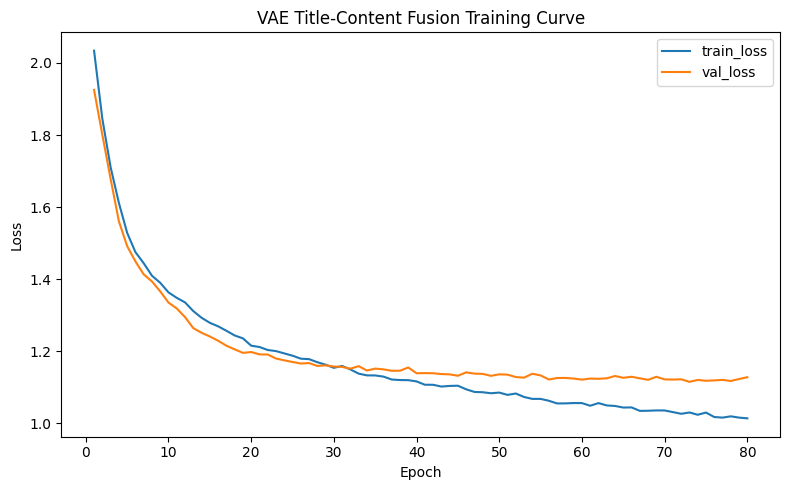

In [28]:
# Train title-content fusion VAE.

SCENARIO_NAME = "VAE_Title_Content_Fusion"

title_scaler = StandardScaler()
content_scaler = StandardScaler()

title_features = title_scaler.fit_transform(title_embeddings).astype(np.float32)
content_features = content_scaler.fit_transform(content_embeddings).astype(np.float32)

vae_fusion_model, vae_fusion_history = train_fusion_vae(
    title_features=title_features,
    content_features=content_features,
    latent_dim=TARGET_N_TOPICS,
    branch_hidden=192,
    fusion_hidden=256,
    dropout=0.10,
    lr=1e-3,
    batch_size=128,
    epochs=80,
    beta=0.01,
    patience=15,
    scenario_name=SCENARIO_NAME,
)

fusion_out_dir = scenario_dir(SCENARIO_NAME)
vae_fusion_history.to_csv(fusion_out_dir / "vae_training_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(vae_fusion_history["epoch"], vae_fusion_history["train_loss"], label="train_loss")
plt.plot(vae_fusion_history["epoch"], vae_fusion_history["val_loss"], label="val_loss")
plt.title("VAE Title-Content Fusion Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(fusion_out_dir / "vae_training_curve.png", dpi=150)
plt.show()

In [29]:
# Extract latent features and topics from the fusion VAE.

vae_fusion_mu, vae_fusion_logvar = get_fusion_vae_latent(
    vae_fusion_model,
    title_features,
    content_features,
)

vae_fusion_labels, vae_fusion_confidence, vae_fusion_kmeans, vae_fusion_probs = kmeans_topics_from_latent(
    vae_fusion_mu,
    n_topics=TARGET_N_TOPICS,
)

vae_fusion_keywords_map = topic_keywords_from_assignments(
    texts=df["text_clean"].tolist(),
    labels=vae_fusion_labels,
    vectorizer=tfidf_vectorizer,
    top_n=TOP_N_WORDS,
    exclude_outlier=False,
)

print("[INFO] VAE fusion labels:", Counter(vae_fusion_labels))
np.save(fusion_out_dir / "vae_fusion_latent_mu.npy", vae_fusion_mu)
np.save(fusion_out_dir / "vae_fusion_topic_probabilities.npy", vae_fusion_probs)

[INFO] VAE fusion labels: Counter({np.int64(2): 354, np.int64(6): 325, np.int64(4): 325, np.int64(5): 302, np.int64(7): 269, np.int64(1): 243, np.int64(3): 201, np.int64(8): 198, np.int64(9): 187, np.int64(0): 183})


In [30]:
vae_fusion_result = save_standard_scenario_outputs(
    scenario_name=SCENARIO_NAME,
    base_df=df,
    text_analyzed=df["text_clean"].tolist(),
    labels=vae_fusion_labels,
    confidence=vae_fusion_confidence,
    keywords_map=vae_fusion_keywords_map,
    tokenized_texts=tokenized_texts,
    feature_for_silhouette=vae_fusion_mu,
    extra_metrics={
        "vae_latent_dim": TARGET_N_TOPICS,
        "vae_beta": 0.01,
        "vae_best_val_loss": float(vae_fusion_history["val_loss"].min()),
        "vae_epochs_run": int(len(vae_fusion_history)),
    },
    model_objects={
        "title_scaler": title_scaler,
        "content_scaler": content_scaler,
        "vae_fusion_kmeans": vae_fusion_kmeans,
    },
)

torch.save(
    vae_fusion_model.state_dict(),
    scenario_dir(SCENARIO_NAME) / "models" / "vae_title_content_fusion_state_dict.pt",
)

# Re-zip after saving the PyTorch state dict.
zip_scenario_output(SCENARIO_NAME)

display(vae_fusion_result["topic_summary"])
display(pd.DataFrame([vae_fusion_result["metrics"]]))

[INFO] Zipped VAE_Title_Content_Fusion outputs to: /content/news_topic_modelling_outputs/vae_title_content_fusion_outputs.zip
[INFO] Saved scenario: VAE_Title_Content_Fusion
[INFO] Document output: news_topic_modelling_outputs/vae_title_content_fusion/vae_title_content_fusion_document_topics.csv
[INFO] Topic summary: news_topic_modelling_outputs/vae_title_content_fusion/vae_title_content_fusion_topic_summary.csv
[INFO] Metrics: news_topic_modelling_outputs/vae_title_content_fusion/vae_title_content_fusion_metrics_summary.csv
[INFO] Zipped VAE_Title_Content_Fusion outputs to: /content/news_topic_modelling_outputs/vae_title_content_fusion_outputs.zip


,scenario,topic_id,topic_name,topic_keywords,document_count,avg_confidence,is_outlier
0,VAE_Title_Content_Fusion,0,"Topic 0: libur, libur nasional, cuti, nasional","libur, libur nasional, cuti, nasional, cuti be...",183,0.343229,False
1,VAE_Title_Content_Fusion,1,"Topic 1: nasional, tim, pemain, timnas","nasional, tim, pemain, timnas, pelatih, olahra...",243,0.265773,False
2,VAE_Title_Content_Fusion,2,"Topic 2: nasional, program, peserta, magang","nasional, program, peserta, magang, pemerintah...",354,0.252874,False
3,VAE_Title_Content_Fusion,3,"Topic 3: pangan, harga, pertanian, amran","pangan, harga, pertanian, amran, beras, ton, n...",201,0.288268,False
4,VAE_Title_Content_Fusion,4,"Topic 4: persen, ekonomi, pertumbuhan, pertumb...","persen, ekonomi, pertumbuhan, pertumbuhan ekon...",325,0.297930,False
5,VAE_Title_Content_Fusion,5,"Topic 5: ekonomi, bank, usaha, bri","ekonomi, bank, usaha, bri, keuangan, program, ...",302,0.269090,False
6,VAE_Title_Content_Fusion,6,"Topic 6: energi, mobil, nasional, industri","energi, mobil, nasional, industri, bbm, pertam...",325,0.254945,False
7,VAE_Title_Content_Fusion,7,"Topic 7: pahlawan, pahlawan nasional, gelar, p...","pahlawan, pahlawan nasional, gelar, presiden, ...",269,0.296217,False
8,VAE_Title_Content_Fusion,8,"Topic 8: bencana, banjir, sumatra, aceh","bencana, banjir, sumatra, aceh, nasional, long...",198,0.311614,False
9,VAE_Title_Content_Fusion,9,"Topic 9: iran, israel, trump, amerika","iran, israel, trump, amerika, serikat, amerika...",187,0.352929,False


,scenario,n_documents,target_n_topics,n_topics_found_excluding_outlier,outlier_count,outlier_ratio,avg_confidence,topic_diversity,coherence_cv,coherence_umass,silhouette_score,vae_latent_dim,vae_beta,vae_best_val_loss,vae_epochs_run
0,VAE_Title_Content_Fusion,2587,10,10,0,0.0,0.287276,0.91,0.712576,-1.384503,0.11895,10,0.01,1.11523,80


## Final Comparison

In [31]:
scenario_names = [
    "LSA",
    "BERTopic",
    "VAE_Contextual_Embedding",
    "VAE_Title_Content_Fusion",
]

metrics_frames = []
doc_frames = []
topic_frames = []

for name in scenario_names:
    base = scenario_dir(name)
    metrics_path = base / f"{clean_filename(name)}_metrics_summary.csv"
    doc_path = base / f"{clean_filename(name)}_document_topics.csv"
    topic_path = base / f"{clean_filename(name)}_topic_summary.csv"

    if metrics_path.exists():
        metrics_frames.append(pd.read_csv(metrics_path))

    if doc_path.exists():
        doc_frames.append(pd.read_csv(doc_path))

    if topic_path.exists():
        topic_frames.append(pd.read_csv(topic_path))

all_metrics = pd.concat(metrics_frames, ignore_index=True) if metrics_frames else pd.DataFrame()
all_docs = pd.concat(doc_frames, ignore_index=True) if doc_frames else pd.DataFrame()
all_topics = pd.concat(topic_frames, ignore_index=True) if topic_frames else pd.DataFrame()

all_metrics_path = OUTPUT_ROOT / "all_scenarios_metrics_summary.csv"
all_docs_path = OUTPUT_ROOT / "all_scenarios_document_topics.csv"
all_topics_path = OUTPUT_ROOT / "all_scenarios_topic_summary.csv"

all_metrics.to_csv(all_metrics_path, index=False)
all_docs.to_csv(all_docs_path, index=False)
all_topics.to_csv(all_topics_path, index=False)

display(all_metrics)
display(all_topics.head(30))

print("[INFO] Combined metrics:", all_metrics_path)
print("[INFO] Combined document topics:", all_docs_path)
print("[INFO] Combined topic summary:", all_topics_path)

,scenario,n_documents,target_n_topics,n_topics_found_excluding_outlier,outlier_count,outlier_ratio,avg_confidence,topic_diversity,coherence_cv,coherence_umass,silhouette_score,lsa_explained_variance_ratio_sum,bertopic_min_topic_size,bertopic_nr_topics,vae_latent_dim,vae_beta,vae_best_val_loss,vae_epochs_run
0,LSA,2587,10,10,0,0.000000,0.317466,0.810000,0.705994,-1.947539,0.068925,0.061665,NaN,NaN,NaN,NaN,NaN,NaN
1,BERTopic,2587,10,9,502,0.194047,0.588717,0.877778,0.677550,-2.314108,0.048006,NaN,10.0,10.0,NaN,NaN,NaN,NaN
2,VAE_Contextual_Embedding,2587,10,10,0,0.000000,0.282680,0.870000,0.701668,-1.323646,0.117707,NaN,NaN,NaN,10.0,0.01,0.492708,79.0
3,VAE_Title_Content_Fusion,2587,10,10,0,0.000000,0.287276,0.910000,0.712576,-1.384503,0.118950,NaN,NaN,NaN,10.0,0.01,1.115230,80.0


,scenario,topic_id,topic_name,topic_keywords,document_count,avg_confidence,is_outlier
0,LSA,0,"Topic 0: ekonomi, nasional, persen, pemerintah","ekonomi, nasional, persen, pemerintah, lebih, ...",1887,0.336517,False
1,LSA,1,"Topic 1: persen, pertumbuhan, ekonomi, pertumb...","persen, pertumbuhan, ekonomi, pertumbuhan ekon...",161,0.232233,False
2,LSA,2,"Topic 2: persen, pahlawan, pahlawan nasional, ...","persen, pahlawan, pahlawan nasional, kuartal, ...",52,0.271865,False
3,LSA,3,"Topic 3: pahlawan, pahlawan nasional, gelar, s...","pahlawan, pahlawan nasional, gelar, soeharto, ...",66,0.222240,False
4,LSA,4,"Topic 4: libur, libur nasional, cuti, cuti ber...","libur, libur nasional, cuti, cuti bersama, nas...",71,0.346306,False
5,LSA,5,"Topic 5: bencana, aceh, banjir, sumatra","bencana, aceh, banjir, sumatra, bencana nasion...",72,0.292068,False
6,LSA,6,"Topic 6: harga, energi, minyak, pasokan","harga, energi, minyak, pasokan, bbm, pahlawan ...",125,0.228154,False
7,LSA,7,"Topic 7: magang, magang nasional, peserta, kem...","magang, magang nasional, peserta, kemnaker, ba...",56,0.298184,False
8,LSA,8,"Topic 8: prabowo, presiden, gizi, mbg","prabowo, presiden, gizi, mbg, presiden prabowo...",38,0.275981,False
9,LSA,9,"Topic 9: kendaraan, mobil, one way, way","kendaraan, mobil, one way, way, one, arus, agu...",59,0.317987,False


[INFO] Combined metrics: news_topic_modelling_outputs/all_scenarios_metrics_summary.csv
[INFO] Combined document topics: news_topic_modelling_outputs/all_scenarios_document_topics.csv
[INFO] Combined topic summary: news_topic_modelling_outputs/all_scenarios_topic_summary.csv


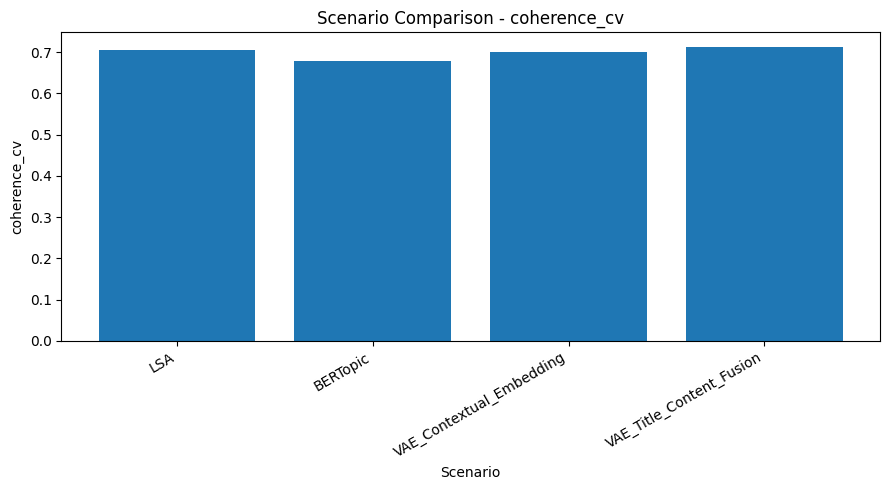

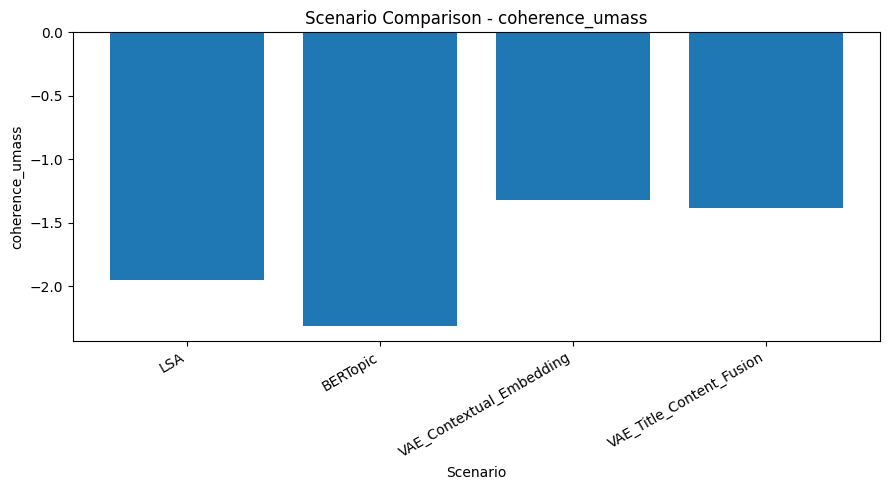

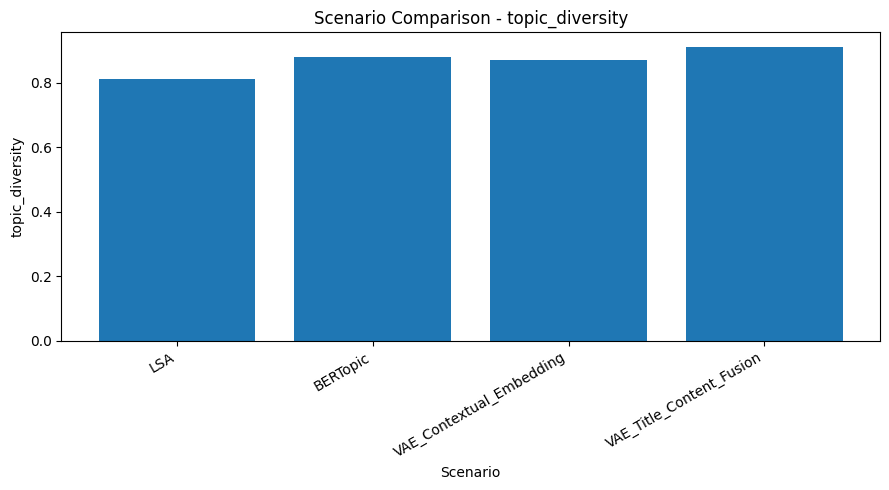

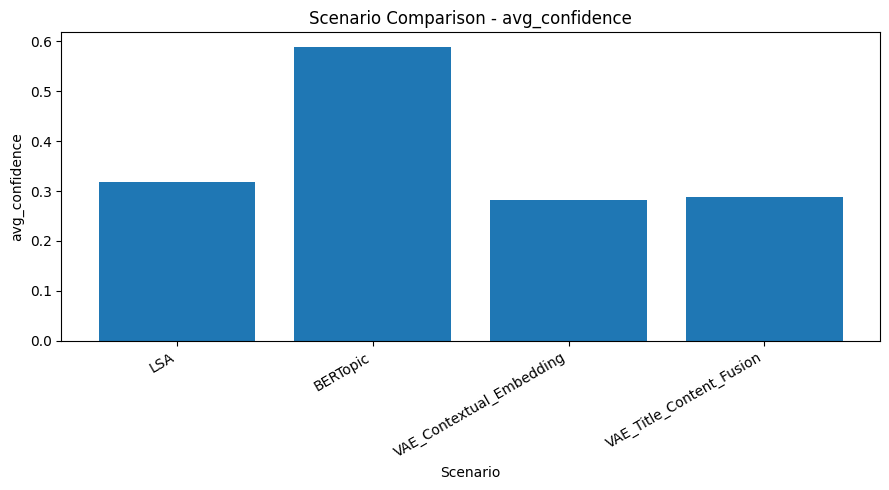

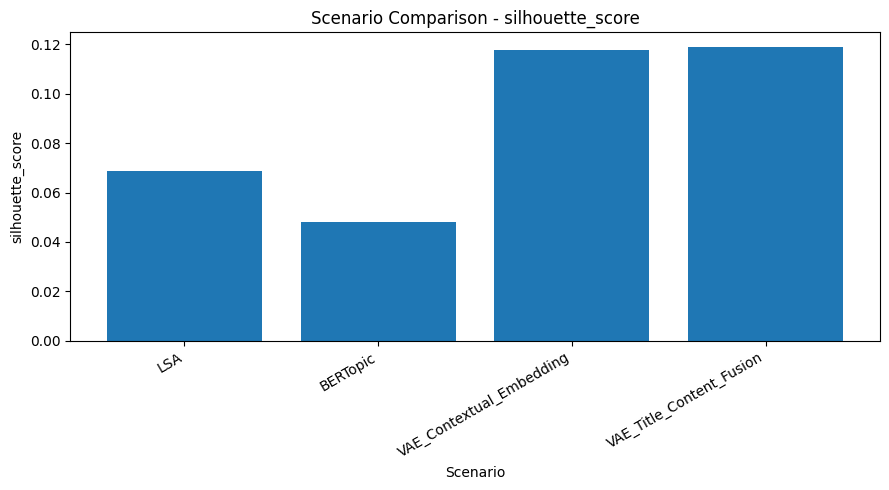

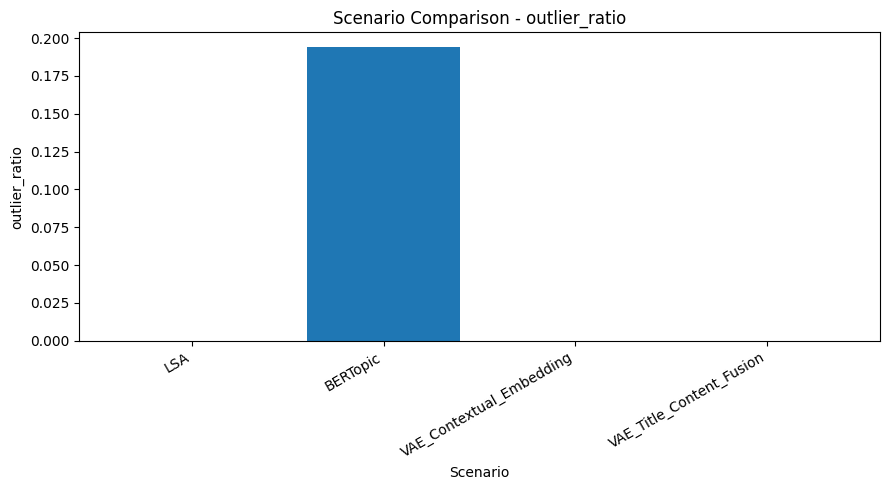

In [32]:
if len(all_metrics) > 0:
    for metric_col in ["coherence_cv", "coherence_umass", "topic_diversity", "avg_confidence", "silhouette_score", "outlier_ratio"]:
        if metric_col in all_metrics.columns:
            plt.figure(figsize=(9, 5))
            plt.bar(all_metrics["scenario"], all_metrics[metric_col])
            plt.title(f"Scenario Comparison - {metric_col}")
            plt.xlabel("Scenario")
            plt.ylabel(metric_col)
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plt.savefig(OUTPUT_ROOT / f"comparison_{metric_col}.png", dpi=150)
            plt.show()

## Discussion

This experiment compares four topic modelling scenarios on the same Indonesian news dataset: LSA, BERTopic, VAE with contextual embeddings, and VAE with title-content fusion. The comparison was designed to keep the experimental setting as consistent as possible across methods, including the same dataset, preprocessing pipeline, target number of topics, and output schema. The main objective was not only to identify which method produced the highest numerical score, but also to analyze whether the generated topics were semantically meaningful, diverse, and practically interpretable for news article exploration.

From the final comparison, the VAE + Title-Content Fusion scenario achieved the strongest overall result. It produced the highest C_V coherence score of 0.7126, the highest topic diversity score of 0.9100, and the highest silhouette score of 0.1190. This indicates that combining title-level and content-level information helped the model construct a more informative latent representation for topic discovery. In news articles, the title usually contains a compact summary of the main event, while the full content provides broader semantic context. Therefore, the fusion strategy gives the model access to both concise topical signals and richer document-level semantics.

The LSA baseline produced a competitive C_V coherence score of 0.7060, but its topic distribution was less balanced. Most documents were assigned to a dominant topic related to general economic and national issues. This behavior is understandable because LSA relies on TF-IDF and truncated singular value decomposition, which capture dominant linear patterns in the term-document matrix. Although this makes LSA simple and efficient, it can struggle to separate fine-grained semantic themes when many articles share frequent words such as "nasional", "pemerintah", "ekonomi", and "persen". As a result, LSA is useful as a classical baseline, but it is less effective for producing balanced and granular news topics.

BERTopic generated highly interpretable topics, such as topics related to economy, national heroes, holidays, Iran-Israel conflict, disasters, football, internship programs, food prices, and Trump-Venezuela issues. This confirms the strength of transformer-based document embeddings and class-based TF-IDF representation for producing readable topic labels. However, BERTopic assigned 502 documents, or around 19.4% of the dataset, to the outlier topic. This is not an implementation error, because BERTopic commonly uses density-based clustering where documents that do not belong strongly to any dense cluster can be labelled as outliers. Nevertheless, the relatively high outlier ratio suggests that the model may require further tuning, such as adjusting UMAP, HDBSCAN, minimum topic size, or applying BERTopic outlier reduction.

The VAE + Contextual Embedding scenario improved the separation of document clusters compared to LSA and BERTopic, as shown by a higher silhouette score of 0.1177. This suggests that the VAE latent space was able to learn a more compact representation of contextual document embeddings. The resulting topics were also semantically reasonable, covering themes such as internship programs, Iran-Israel conflict, economic growth, national holidays, national heroes, food prices, energy, disasters, banking, and football. However, its topic diversity and coherence were still slightly lower than the title-content fusion variant, indicating that contextual content alone may miss some strong topical cues that are explicitly stated in article titles.

The comparison between the two VAE scenarios is particularly important. Both models used neural latent representations, but the title-content fusion model consistently improved over the contextual-only model in C_V coherence, topic diversity, and silhouette score. This supports the assumption that title and content contribute complementary information in news topic modelling. The title acts as a high-density topical signal, while the content provides semantic expansion and contextual grounding. By combining both, the model can produce topics that are more coherent, less redundant, and more balanced across document groups.

Although the VAE-based methods achieved promising results, the absolute silhouette scores are still relatively low. This means that the topic clusters are not perfectly separated in the latent space. This is expected in news datasets because many articles share overlapping vocabulary, entities, and national-level contexts. For example, economic policy, government programs, national holidays, and public services may share common words even when they belong to different topical themes. Therefore, the evaluation should not rely on a single metric. Coherence, diversity, silhouette score, topic distribution, and human interpretability should be considered together.

Overall, the results show that neural topic modelling with contextual embeddings can improve topic separation and topic quality compared to a purely linear baseline. More importantly, the proposed VAE + Title-Content Fusion scenario provides the best trade-off between coherence, diversity, and interpretability. This makes it the most suitable scenario in this experiment for discovering structured themes from Indonesian news articles.

## Conclusion

This notebook presented a comparative study of four topic modelling approaches for Indonesian news articles: LSA, BERTopic, VAE + Contextual Embedding, and VAE + Title-Content Fusion. The experiment used the same dataset, preprocessing pipeline, target topic setting, and output format to make the comparison more consistent and interpretable.

Based on the final evaluation, VAE + Title-Content Fusion achieved the best overall performance. It obtained the highest C_V coherence, the highest topic diversity, and the highest silhouette score among all scenarios. The generated topics were also semantically meaningful and relatively balanced, covering important news themes such as national holidays, football, internship programs, food prices, economic growth, banking, energy, national heroes, disasters, and international conflict. These results indicate that combining title and content representations can help the model capture both concise topical cues and deeper contextual meaning.

LSA performed well as a classical baseline, especially in terms of coherence, but it tended to assign too many documents to one dominant topic. BERTopic produced readable and specific topics, but it also generated a relatively high number of outliers. Meanwhile, VAE + Contextual Embedding showed better latent-space separation than LSA and BERTopic, but it was slightly weaker than the title-content fusion approach. Therefore, the fusion-based VAE model can be considered the most effective method in this experiment.

The findings suggest that title-content fusion is a useful strategy for neural topic modelling on news datasets. Since news titles often summarize the central issue of an article, while the content provides detailed context, combining both representations improves the quality of learned topic structures. Future work can extend this experiment by tuning the number of topics, testing alternative multilingual sentence embedding models, applying BERTopic outlier reduction, experimenting with deeper VAE architectures, and evaluating topic quality through human judgment.

## References

Abdelrazek, A., Eid, Y., Gawish, E., Medhat, W., & Hassan, A. (2023). Topic modeling algorithms and applications: A survey. *Information Systems, 112*, 102131. https://doi.org/10.1016/j.is.2022.102131

Bianchi, F., Terragni, S., & Hovy, D. (2021). Pre-training is a hot topic: Contextualized document embeddings improve topic coherence. *Proceedings of the 59th Annual Meeting of the Association for Computational Linguistics and the 11th International Joint Conference on Natural Language Processing*, 759–766. https://aclanthology.org/2021.acl-short.96/

Grootendorst, M. (2022). BERTopic: Neural topic modeling with a class-based TF-IDF procedure. *arXiv preprint arXiv:2203.05794*. https://arxiv.org/abs/2203.05794

Kingma, D. P., & Welling, M. (2014). Auto-encoding variational Bayes. *International Conference on Learning Representations*. https://arxiv.org/abs/1312.6114

Nguyen, T., Pham, D.-T., Nguyen, Q. D., Ngo Van, L., Nguyen Duc, A., & Dinh Viet, S. (2025). TopiCOT: Neural topic model aligning with pre-trained clustering and optimal transport. *Neurocomputing, 654*, 131268. https://doi.org/10.1016/j.neucom.2025.131268

Srivastava, A., & Sutton, C. (2017). Autoencoding variational inference for topic models. *International Conference on Learning Representations*. https://arxiv.org/abs/1703.01488

Zhu, Y., & Liu, Y. (2025). Gibbs-BERTopic: A hybrid approach for short text topic modeling. *IEEE Access, 13*, 49162–49173. https://doi.org/10.1109/ACCESS.2025.3552221